In [3]:
import sys
sys.path.append('../../Common/') # Module path for CommonMT5

import CommonMT5 # File for common functions

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import talib 

In [5]:
import pandas as pd
import plotly.graph_objects as go
import redis
import numpy as np
from datetime import datetime
import MetaTrader5 as mt5
from datetime import datetime, timedelta

# ##############################################Step 0: Khai báo##############################################
symbol = 'GBPUSD.sml'
from_date = (datetime.now() - timedelta(days=0)).strftime('%Y-%m-%d')  # Lấy ngày hiện tại
to_date = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
timeframe = mt5.TIMEFRAME_M1

# ##############################################Step 1: Lấy dữ liệu##############################################
data = CommonMT5.CommonMT5.loaddataMT5_FromTo(symbol, from_date, to_date, timeframe)
# data.set_index('Datetime', inplace=True)
print(data)
# ##############################################Step 2: Chiến lược##############################################  
# Tính toán các chỉ báo kỹ thuật
data['Momentum'] = talib.MOM(data['Close'], timeperiod=14)
data['RSI'] = talib.RSI(data['Close'], timeperiod=14)

# Đảm bảo không có giá trị NaN trong Momentum, RSI
data['Momentum'] = data['Momentum'].bfill().ffill() # Điền giá trị NaN bằng phương pháp backward fill và forward fill
data['RSI'] = data['RSI'].bfill().ffill()

# Tạo features (X) và target (y)
X = data[['Close', 'Momentum', 'RSI']].shift(1)  # Dùng dữ liệu của ngày hôm trước để dự đoán
y = data['Close']  # Giá đóng cửa mà chúng ta muốn dự đoán

# Tiếp tục với việc chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.bfill().ffill()
y_train = y_train.bfill().ffill()

# Huấn luyện mô hình
model = LinearRegression()
model.fit(X_train, y_train)

# Đảm bảo không có giá trị NaN trong X trước khi dự đoán
X = X.bfill().ffill()

# Dự đoán giá đóng cửa sử dụng X đã điền giá trị NaN
data['Predicted_Close'] = model.predict(X)

# Có thể sử dụng MSE để đánh giá mô hình ổn thì làm bước kế tiếp
# Tính Mean Squared Error (MSE) giữa giá trị thực tế và giá trị dự đoán trên tập kiểm tra
mse = mean_squared_error(data['Close'], data['Predicted_Close'])
print(f'Mean Squared Error (MSE): {mse}')

# Định nghĩa tín hiệu mua dựa trên điều kiện: Dự đoán giá tăng, Momentum dương và RSI dưới 70
data['Buy_Signal'] = ((data['Predicted_Close'] > data['Close']) & (data['Momentum'] > 0) & (data['RSI'] < 50))

# Định nghĩa tín hiệu bán dựa trên điều kiện: Dự đoán giá giảm, Momentum âm và RSI trên 30
data['Sell_Signal'] = ((data['Predicted_Close'] < data['Close']) & (data['Momentum'] < 0) & (data['RSI'] > 50))


                Datetime     Open     High      Low    Close  Volume
0    2025-11-13 17:00:00  1.31812  1.31814  1.31759  1.31768     313
1    2025-11-13 17:01:00  1.31768  1.31773  1.31757  1.31761     332
2    2025-11-13 17:02:00  1.31760  1.31773  1.31758  1.31770     360
3    2025-11-13 17:03:00  1.31770  1.31775  1.31747  1.31749     340
4    2025-11-13 17:04:00  1.31748  1.31781  1.31746  1.31780     290
...                  ...      ...      ...      ...      ...     ...
1366 2025-11-14 15:52:00  1.31623  1.31631  1.31613  1.31615     221
1367 2025-11-14 15:53:00  1.31615  1.31630  1.31613  1.31614     202
1368 2025-11-14 15:54:00  1.31615  1.31637  1.31613  1.31631     153
1369 2025-11-14 15:55:00  1.31632  1.31657  1.31632  1.31649     188
1370 2025-11-14 15:56:00  1.31649  1.31655  1.31649  1.31652      80

[1371 rows x 6 columns]
Mean Squared Error (MSE): 4.920340136483635e-08


In [6]:
data

,Datetime,Open,High,Low,Close,Volume,Momentum,RSI,Predicted_Close,Buy_Signal,Sell_Signal
0,2025-11-13 17:00:00,1.31812,1.31814,1.31759,1.31768,313,0.00024,55.882353,1.317682,False,False
1,2025-11-13 17:01:00,1.31768,1.31773,1.31757,1.31761,332,0.00024,55.882353,1.317682,False,False
2,2025-11-13 17:02:00,1.31760,1.31773,1.31758,1.31770,360,0.00024,55.882353,1.317612,False,False
3,2025-11-13 17:03:00,1.31770,1.31775,1.31747,1.31749,340,0.00024,55.882353,1.317702,False,False
4,2025-11-13 17:04:00,1.31748,1.31781,1.31746,1.31780,290,0.00024,55.882353,1.317493,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1366,2025-11-14 15:52:00,1.31623,1.31631,1.31613,1.31615,221,-0.00068,42.424345,1.316235,False,False
1367,2025-11-14 15:53:00,1.31615,1.31630,1.31613,1.31614,202,-0.00051,42.245316,1.316145,False,False
1368,2025-11-14 15:54:00,1.31615,1.31637,1.31613,1.31631,153,-0.00028,46.387307,1.316133,False,False
1369,2025-11-14 15:55:00,1.31632,1.31657,1.31632,1.31649,188,-0.00015,50.440154,1.316307,False,True


In [7]:
data.to_csv('data.csv', index=False)

g:\My Drive\0. Day ben ngoai (___)\Day Cole\Khoa Auto Trading K13\Buổi 17.18.19\2. Order Follower\../../Common\CommonBacktest.py:279: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '76379.99999999999' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.at[index, 'Capital'] = capital  # Cập nhật số vốn sau mỗi giao dịch


Ngày vào lệnh đầu tiên: 16
Tổng lợi nhuận: -923951.0
Tổng giá trị tài khoản cuối cùng: 76048.99999999997
Lợi nhuận thị trường: -0.08803351344786502%
Lợi nhuận chiến lược: -92.3951%


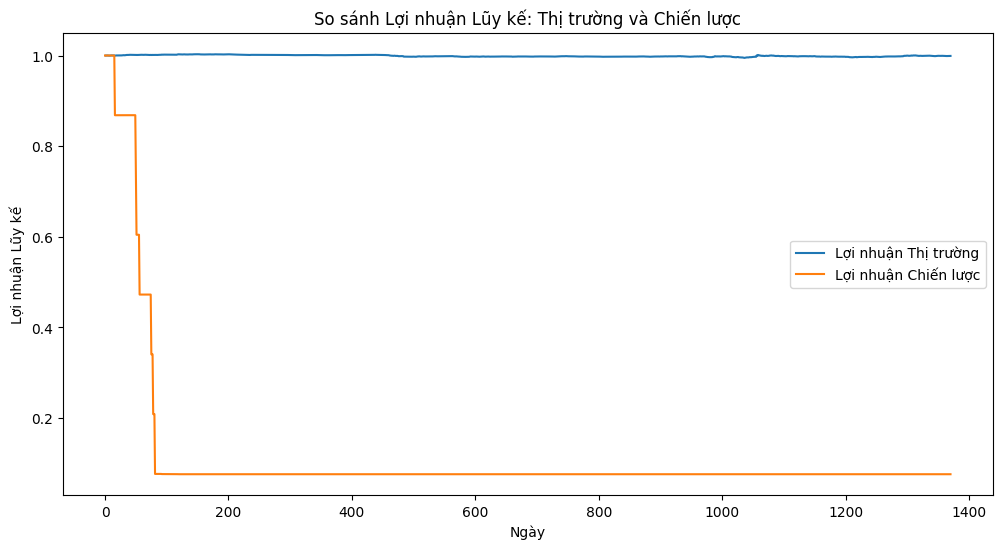

,Datetime,Open,High,Low,Close,Volume,Momentum,RSI,Predicted_Close,Buy_Signal,Sell_Signal,Position_Buy,Position_Sell,Trade_Action,Capital,Market_Return,Cumulative_Market_Returns,Strategy_Value,Cumulative_Strategy_Returns
0,2025-11-13 17:00:00,1.31812,1.31814,1.31759,1.31768,313,0.00024,55.882353,1.317682,False,False,NaN,NaN,,1000000.0,NaN,NaN,1000000.0,1.000000
1,2025-11-13 17:01:00,1.31768,1.31773,1.31757,1.31761,332,0.00024,55.882353,1.317682,False,False,False,False,,1000000.0,-0.000053,0.999947,1000000.0,1.000000
2,2025-11-13 17:02:00,1.31760,1.31773,1.31758,1.31770,360,0.00024,55.882353,1.317612,False,False,False,False,,1000000.0,0.000068,1.000015,1000000.0,1.000000
3,2025-11-13 17:03:00,1.31770,1.31775,1.31747,1.31749,340,0.00024,55.882353,1.317702,False,False,False,False,,1000000.0,-0.000159,0.999856,1000000.0,1.000000
4,2025-11-13 17:04:00,1.31748,1.31781,1.31746,1.31780,290,0.00024,55.882353,1.317493,False,False,False,False,,1000000.0,0.000235,1.000091,1000000.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1366,2025-11-14 15:52:00,1.31623,1.31631,1.31613,1.31615,221,-0.00068,42.424345,1.316235,False,False,False,False,,76049.0,-0.000068,0.998839,76049.0,0.076049
1367,2025-11-14 15:53:00,1.31615,1.31630,1.31613,1.31614,202,-0.00051,42.245316,1.316145,False,False,False,False,,76049.0,-0.000008,0.998831,76049.0,0.076049
1368,2025-11-14 15:54:00,1.31615,1.31637,1.31613,1.31631,153,-0.00028,46.387307,1.316133,False,False,False,False,,76049.0,0.000129,0.998960,76049.0,0.076049
1369,2025-11-14 15:55:00,1.31632,1.31657,1.31632,1.31649,188,-0.00015,50.440154,1.316307,False,True,False,False,,76049.0,0.000137,0.999097,76049.0,0.076049


In [9]:
import CommonBacktest

# backtestForex(data, initial_capital, lot_per_trade, leverage, tp_point, sl_point):  # Forex
dataBacktest = CommonBacktest.CommonBacktest.backtestForex(data, 1000000, 1, 1, 100, 100)
dataBacktest